In [11]:
from statistics import LinearRegression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression

In [12]:
data = pd.read_csv('real_estate_price_size_year.csv')
data.head()

,price,size,year
0,234314.144,643.09,2015
1,228581.528,656.22,2009
2,281626.336,487.29,2018
3,401255.608,1504.75,2015
4,458674.256,1275.46,2009


In [13]:
data.describe()

,price,size,year
count,100.000000,100.000000,100.000000
mean,292289.470160,853.024200,2012.600000
std,77051.727525,297.941951,4.729021
min,154282.128000,479.750000,2006.000000
25%,234280.148000,643.330000,2009.000000
50%,280590.716000,696.405000,2015.000000
75%,335723.696000,1029.322500,2018.000000
max,500681.128000,1842.510000,2018.000000


In [14]:
x = data[['size','year']]
y = data['price']

In [15]:
reg = LinearRegression()
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
reg.intercept_

np.float64(-5772267.017463278)

In [17]:
reg.coef_

array([ 227.70085401, 2916.78532684])

In [18]:
reg.score(x,y)

0.7764803683276793

In [19]:
def adj_r2(x,y):
    r2 = reg.score(x,y)
    n = x.shape[0]
    p = x.shape[1]
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    return adjusted_r2

In [20]:
adj_r2(x,y)

0.77187171612825

In [21]:
reg.predict([[750,2009]])

/Users/harshalbhujade/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([258330.34465995])

In [22]:
from sklearn.feature_selection import f_regression

In [23]:
f_regression(x,y)

(array([285.92105192,   0.85525799]), array([8.12763222e-31, 3.57340758e-01]))

In [24]:
p_values = f_regression(x,y)[1]
p_values

array([8.12763222e-31, 3.57340758e-01])

In [25]:
p_values.round(3)

array([0.   , 0.357])

SUMMARY TABLE

In [30]:
reg.summary = pd.DataFrame(data = x.columns.values, columns=['Features'])
reg.summary ['Coefficients'] = reg.coef_
reg.summary ['p-values'] = p_values.round(3)
reg.summary

,Features,Coefficients,p-values
0,size,227.700854,0.000
1,year,2916.785327,0.357


It seems that 'Year' is not event significant, therefore we should remove it from the model.

In [ ]:
import seaborn as sns

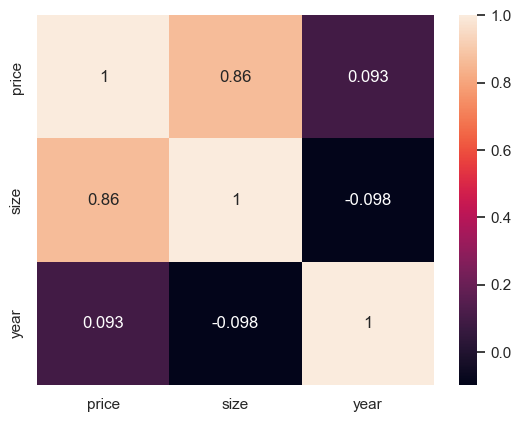

In [27]:
sns.heatmap(data.corr(), annot=True)
plt.show()

In [37]:
size = float(input("Enter size of house: "))
year = float(input("Enter year of house: "))

price = reg.predict([[size,year]])

print(f"Predicted Price: ₹{price[0]:,.2f}")


Predicted Price: ₹246,945.30


/Users/harshalbhujade/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


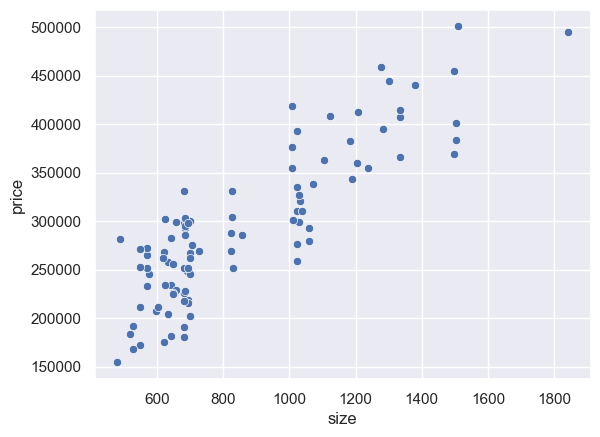

In [31]:
sns.scatterplot(x = 'size', y = 'price', data = data[['size','price']])
plt.show()